In [1]:
from cv2 import kmeans
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import load_iris, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# read data

In [30]:
df=pd.read_csv(f"Mall_Customers.csv")
df.head()
 

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


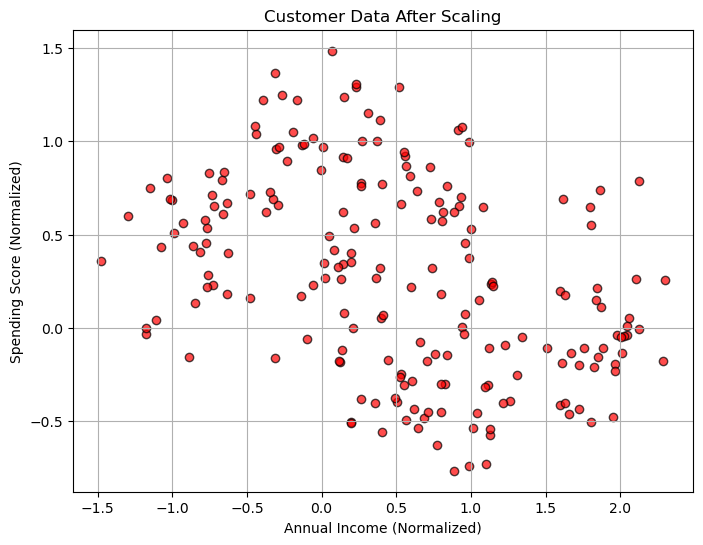

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='red' \
'', edgecolors='k', alpha=0.7)
plt.title('Customer Data After Scaling')
plt.xlabel('Annual Income (Normalized)')
plt.ylabel('Spending Score (Normalized)')
plt.grid(True)
plt.show()

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

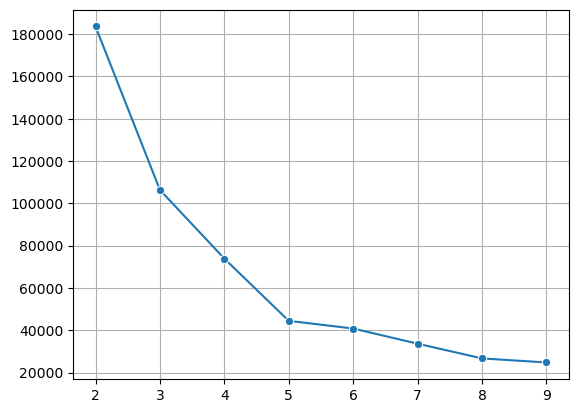

In [5]:
n_cluster_values = range(2, 10)
scores = []

for n_clusters in n_cluster_values:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    y_pred = kmeans.fit_predict(X)
    
    scores.append(kmeans.inertia_)

sns.lineplot(x=n_cluster_values, y=scores, marker='o')
plt.xticks(n_cluster_values)
plt.grid()
plt.show()

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

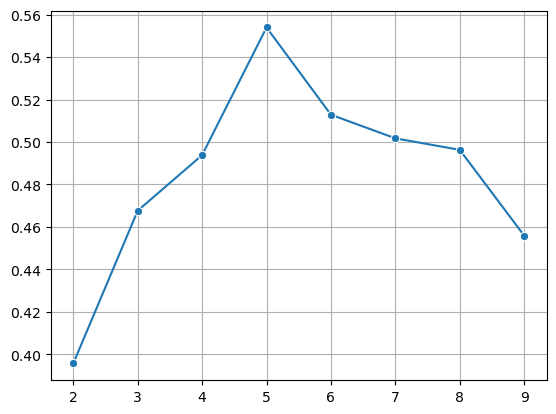

In [6]:
from sklearn.metrics import silhouette_score

n_cluster_values = range(2, 10)
scores = []

for n_clusters in n_cluster_values:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    y_pred = kmeans.fit_predict(X)
    
    scores.append(silhouette_score(X, y_pred))

sns.lineplot(x=n_cluster_values, y=scores, marker='o')
plt.xticks(n_cluster_values)
plt.grid()
plt.show()

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_pred = kmeans.fit_predict(X)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


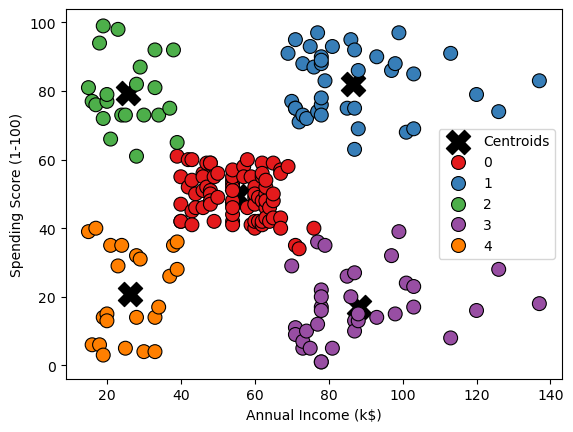

In [8]:
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='black', marker='X', label='Centroids')
          
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue=y_pred, palette='Set1', s=100, edgecolor='k')
plt.show()

In [13]:
from sklearn.datasets import make_moons

Text(0.5, 1.0, 'Moons Dataset')

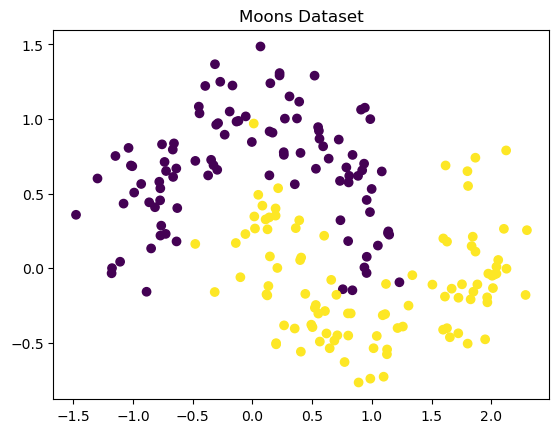

In [19]:
from sklearn.datasets import make_moons
X,y = make_moons(n_samples=200, noise=0.2, random_state=42)
X.shape
y.shape
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('Moons Dataset')

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


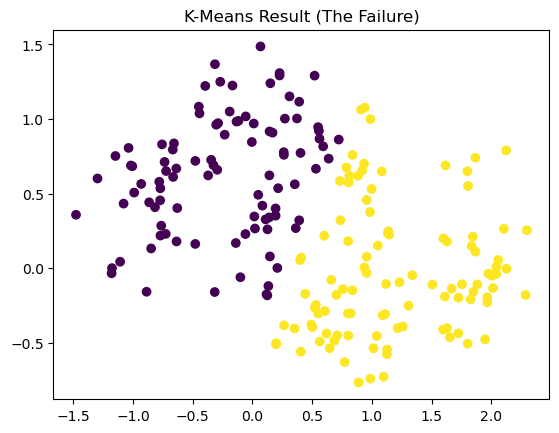

In [ ]:
km = KMeans(n_clusters=2, random_state=42)
y_km = km.fit_predict(X)
 
plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis')
plt.title('K-Means Result (The Failure)')
plt.show()


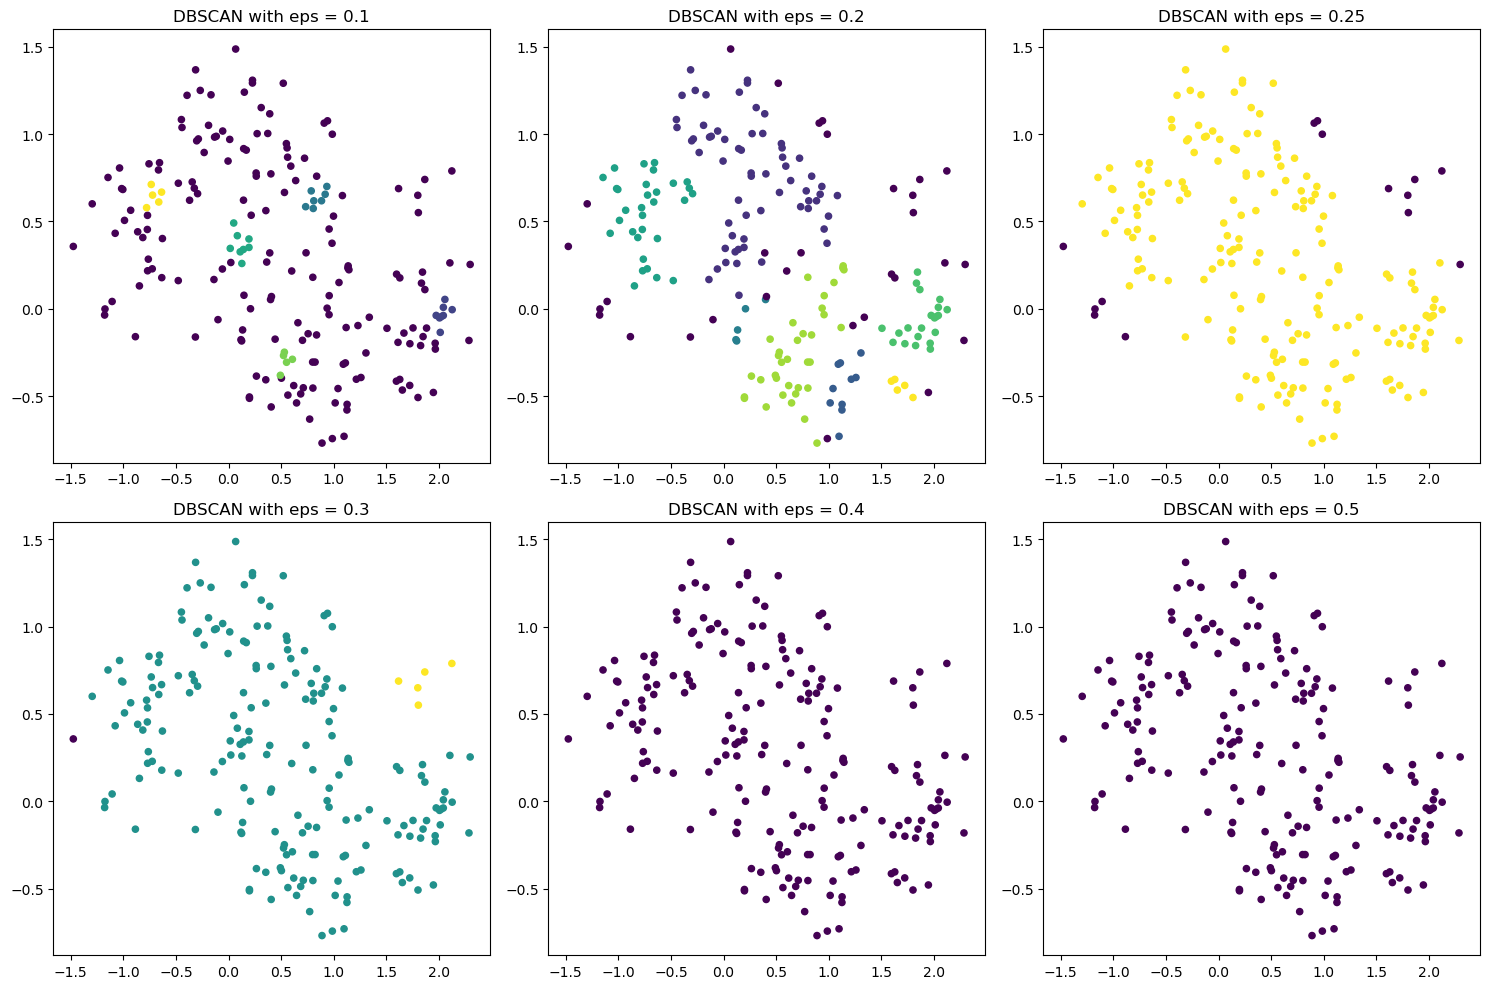

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
 
eps_values = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5]

plt.figure(figsize=(15, 10))

for i, e in enumerate(eps_values):
    plt.subplot(2, 3, i+1) 
    dbscan = DBSCAN(eps=e, min_samples=5)
    y_pred = dbscan.fit_predict(X)
    
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=20)
    plt.title(f'DBSCAN with eps = {e}')

plt.tight_layout()
plt.show()


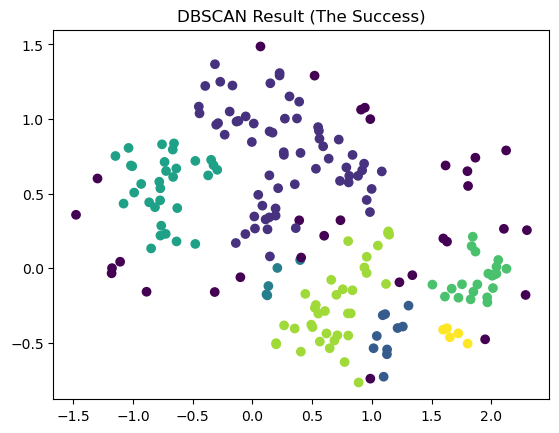

In [28]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
 
plt.scatter(X[:, 0], X[:, 1], c=y_dbscan, cmap='viridis')
plt.title('DBSCAN Result (The Success)')
plt.show()


# 
K-Means Performance:
K-Means struggled to identify the true patterns in the non-spherical data (Moons dataset). Since it relies on distance from a central point, it incorrectly split the curved shapes into linear segments, failing to capture the natural geometry of the clusters.
DBSCAN Performance:
DBSCAN demonstrated superior flexibility by following the density of the data points rather than assuming a specific shape. By tuning the eps parameter, it was able to traverse the curved paths of the moons, effectively separating the two distinct clusters that K-Means missed.
Final Insight:
While K-Means is efficient for well-separated, globular clusters (like the Mall Customers segments), DBSCAN is the preferred choice for complex, overlapping, or non-linear datasets where spatial density is the key defining factor.
